# BlockGen: comparing three generative approaches for voxel structures

This notebook trains and compares **three** generative models for Minecraft voxel
structures on a small subset (max-dim &le; 24), all sharing one tokenizer and one
nearest-neighbor novelty evaluation. No text embeddings are used (LegoGPT-style).

| Track | Model | How variable size is handled |
|------|-------|------------------------------|
| **A** | Autoregressive token transformer (`VoxelTransformerAR`) | EOS-terminated token stream — no fixed grid |
| **B** | Masked discrete diffusion 3D-UNet (`VoxelUNet3D`) | fixed canonical 24&sup3; grid, center-padded |
| **C** | Graph latent VAE (`LargePyGGraphGenerator`) | size-agnostic graph + learned size |

The goal is to **generate new structures and prove they are new**: for each sample we
find its nearest training neighbors by occupancy IoU and render them side by side.


## 0. Setup
Build the cached subset on first run (skips the ~184 corrupt files), then load it.

In [1]:
import warnings, random, numpy as np, torch
warnings.filterwarnings("ignore")
random.seed(0); np.random.seed(0); torch.manual_seed(0)

MAX_DIM = 24
MAX_SEQ_LEN = 1024
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

import os
from blockgen.data.build_cache import CacheConfig, build_cache, cache_path, load_cached_structures
cfg = CacheConfig(max_dim=MAX_DIM)
if not os.path.exists(cache_path(cfg)):
    print(build_cache(cfg))

device: cuda


In [2]:
from blockgen.utils.serialize import build_block_vocab, structure_to_tokens

structures = load_cached_structures(max_dim=MAX_DIM)
vocab = build_block_vocab(structures, max_dim=MAX_DIM)

# Shared subset across all tracks: structures whose token sequence fits MAX_SEQ_LEN.
subset = [s for s in structures if 2 < len(structure_to_tokens(s, vocab)) <= MAX_SEQ_LEN]
print(f"cached structures : {len(structures)}")
print(f"vocab size        : {vocab.vocab_size}  ({vocab.num_blocks} block classes)")
print(f"training subset   : {len(subset)} structures (seq <= {MAX_SEQ_LEN})")
assert subset, ("Empty subset! The cache is empty or unreadable — re-run the build "
                "cache cell above, or from a terminal: python -m blockgen.data.build_cache --max-dim 24")
occ = np.array([int(s.occupied_mask.sum()) for s in subset])
print(f"blocks/structure  : median {int(np.median(occ))}, p90 {int(np.percentile(occ,90))}, max {occ.max()}")

cached structures : 2892
vocab size        : 454  (427 block classes)
training subset   : 896 structures (seq <= 1024)
blocks/structure  : median 124, p90 221, max 255


### Sanity-check the renderer on real data
This is the cell that used to crash on corrupt files — now it draws from the clean cache.

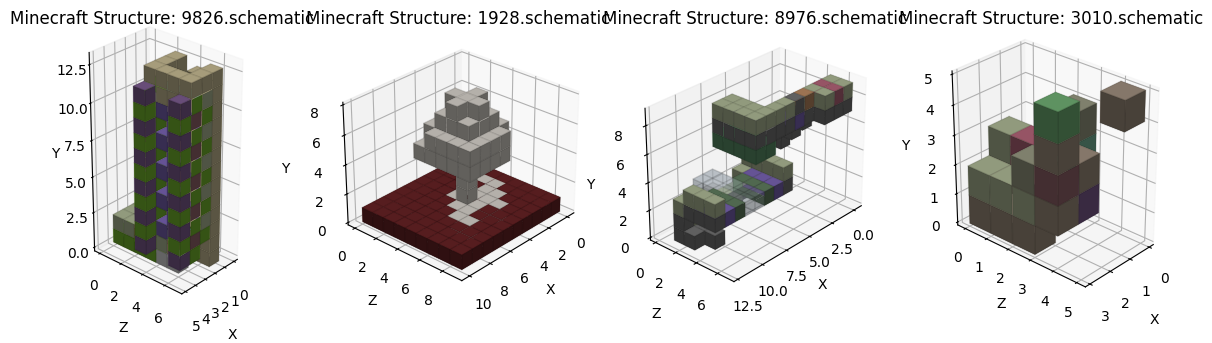

In [3]:
import matplotlib.pyplot as plt
from blockgen.renderer.render import render_schem

fig = plt.figure(figsize=(12, 3))
for i, s in enumerate(random.sample(subset, 4)):
    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    render_schem(s, ax=ax, show=False)
plt.tight_layout(); plt.show()

## Track A — Autoregressive token transformer (LegoGPT-style)
Serialize each structure to `[BOS, (X,Y,Z,BLOCK)*, EOS]` and train next-token prediction.

In [4]:
from blockgen.training.train_ar import train_ar, ARTrainConfig, sample_structures as sample_ar

model_ar, hist_ar = train_ar(subset, vocab, ARTrainConfig(
    max_seq_len=MAX_SEQ_LEN, d_model=256, nhead=8, num_layers=5,
    dim_feedforward=512, epochs=25, batch_size=16, device=DEVICE, log_every=5))
gen_ar = sample_ar(model_ar, vocab, num_samples=24, temperature=0.9, top_k=40)
print("occupied voxels:", sorted(int(s.occupied_mask.sum()) for s in gen_ar))

[AR] epoch   0  loss 3.7983  (n_seq=896)
[AR] epoch   5  loss 1.5698  (n_seq=896)
[AR] epoch  10  loss 1.0785  (n_seq=896)
[AR] epoch  15  loss 0.8808  (n_seq=896)
[AR] epoch  20  loss 0.7751  (n_seq=896)
[AR] epoch  24  loss 0.7006  (n_seq=896)
occupied voxels: [6, 25, 33, 40, 46, 46, 61, 75, 80, 116, 130, 150, 156, 158, 160, 162, 171, 180, 196, 208, 211, 211, 215, 236]


## Track B — Masked discrete diffusion (3D-UNet)
Voxel grids are ~99% air, so the air class is down-weighted; sampling is the iterative MaskGIT unmask.

In [5]:
from blockgen.training.train_diffusion import (
    train_diffusion, DiffusionTrainConfig, calibrate_air_bias, sample_structures as sample_diff)

model_diff, hist_diff = train_diffusion(subset, vocab, DiffusionTrainConfig(
    grid=MAX_DIM, base_channels=48, epochs=40, batch_size=16,
    air_weight=0.05, device=DEVICE, log_every=10))

# Diffusion occupancy is sensitive to training randomness; auto-pick the air_bias
# whose sampled density matches the training median so samples aren't empty/blobs.
target_occ = float(np.median([int(s.occupied_mask.sum()) for s in subset]))
air_bias = calibrate_air_bias(model_diff, vocab, target_occ, grid=MAX_DIM, steps=18, device=DEVICE)
print(f"calibrated air_bias = {air_bias} (target occupancy ~{int(target_occ)})")

gen_diff = sample_diff(model_diff, vocab, num_samples=24, grid=MAX_DIM, steps=18,
                       air_bias=air_bias, device=DEVICE)
print("occupied voxels:", sorted(int(s.occupied_mask.sum()) for s in gen_diff))

[DIFF] epoch   0  loss 0.2627  (n=896)
[DIFF] epoch  10  loss 0.0496  (n=896)
[DIFF] epoch  20  loss 0.0400  (n=896)
[DIFF] epoch  30  loss 0.0363  (n=896)
[DIFF] epoch  39  loss 0.0328  (n=896)
calibrated air_bias = 0.0 (target occupancy ~124)
occupied voxels: [132, 144, 152, 159, 165, 169, 174, 185, 186, 189, 189, 196, 199, 205, 217, 224, 226, 230, 241, 248, 250, 257, 297, 350]


## Track C — Graph latent VAE
Encode the block+port PyG graph &rarr; latent &rarr; decode the same token stream. Sample `z ~ N(0, I)`.

In [6]:
from blockgen.training.train_graph import train_graph, GraphTrainConfig, sample_structures as sample_graph

model_graph, hist_graph = train_graph(subset, vocab, GraphTrainConfig(
    max_seq_len=MAX_SEQ_LEN, hidden_dim=192, latent_dim=128, encoder_layers=4,
    decoder_layers=2, num_heads=4, epochs=30, batch_size=16, device=DEVICE, log_every=5))
gen_graph = sample_graph(model_graph, vocab, num_samples=24, max_len=MAX_SEQ_LEN,
                         temperature=0.9, top_k=40, device=DEVICE)
print("occupied voxels:", sorted(int(s.occupied_mask.sum()) for s in gen_graph))

[GRAPH] epoch   0  loss 3.8346  recon 3.8337  kl 0.8153  (n=896)
[GRAPH] epoch   5  loss 1.5235  recon 1.5225  kl 0.9745  (n=896)
[GRAPH] epoch  10  loss 1.0410  recon 1.0400  kl 0.9723  (n=896)
[GRAPH] epoch  15  loss 0.8750  recon 0.8740  kl 1.0199  (n=896)
[GRAPH] epoch  20  loss 0.7831  recon 0.7819  kl 1.1289  (n=896)
[GRAPH] epoch  25  loss 0.7167  recon 0.7154  kl 1.2878  (n=896)
[GRAPH] epoch  29  loss 0.6774  recon 0.6760  kl 1.3807  (n=896)
occupied voxels: [1, 6, 10, 13, 20, 20, 25, 30, 38, 44, 49, 51, 55, 72, 79, 126, 145, 149, 150, 159, 169, 205, 209, 237]


## Novelty evaluation — are the samples genuinely new?

For every generated structure we voxelize into a common 24&sup3; grid and find its
nearest training neighbors by occupancy IoU.

- **mean_nn_iou** &mdash; average best IoU to the training set. Low &rArr; novel; near 1.0 &rArr; memorized.
- **duplicate_rate** &mdash; fraction of samples that are near-copies (IoU &ge; 0.95).
- **diversity** &mdash; 1 &minus; mean pairwise IoU among samples (high = varied).
- **validity_rate** &mdash; fraction forming a single connected component.


In [7]:
from blockgen.eval.novelty import evaluate_novelty, summary_row

tracks = {"A: AR transformer": gen_ar, "B: diffusion": gen_diff, "C: graph VAE": gen_graph}
reports = {name: evaluate_novelty(gen, subset, vocab, grid=MAX_DIM, k=3) for name, gen in tracks.items()}

# Self-check: a training structure must have NN-IoU == 1.0 against the training set.
self_iou = evaluate_novelty(subset[:6], subset, vocab, grid=MAX_DIM, k=1).nn_iou
print("self NN-IoU (expect 1.0):", np.round(self_iou, 3).tolist(), "\n")

rows = [summary_row(name, rep) for name, rep in reports.items()]
cols = ["track", "mean_nn_iou", "duplicate_rate", "diversity", "validity_rate", "mean_block_agreement"]
widths = {c: max(len(c), *(len(f"{r[c]}") for r in rows)) for c in cols}
print(" | ".join(c.ljust(widths[c]) for c in cols))
print("-+-".join("-" * widths[c] for c in cols))
for r in rows:
    print(" | ".join(f"{r[c]}".ljust(widths[c]) for c in cols))

self NN-IoU (expect 1.0): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0] 

track             | mean_nn_iou | duplicate_rate | diversity | validity_rate | mean_block_agreement
------------------+-------------+----------------+-----------+---------------+---------------------
A: AR transformer | 0.429       | 0.0            | 0.897     | 0.167         | 0.031               
B: diffusion      | 0.558       | 0.0            | 0.595     | 0.167         | 0.007               
C: graph VAE      | 0.153       | 0.0            | 0.986     | 0.083         | 0.003               


### Side-by-side: each generated sample vs its nearest training neighbors
If the left column differs from the neighbor columns, the model is producing genuinely new structures.

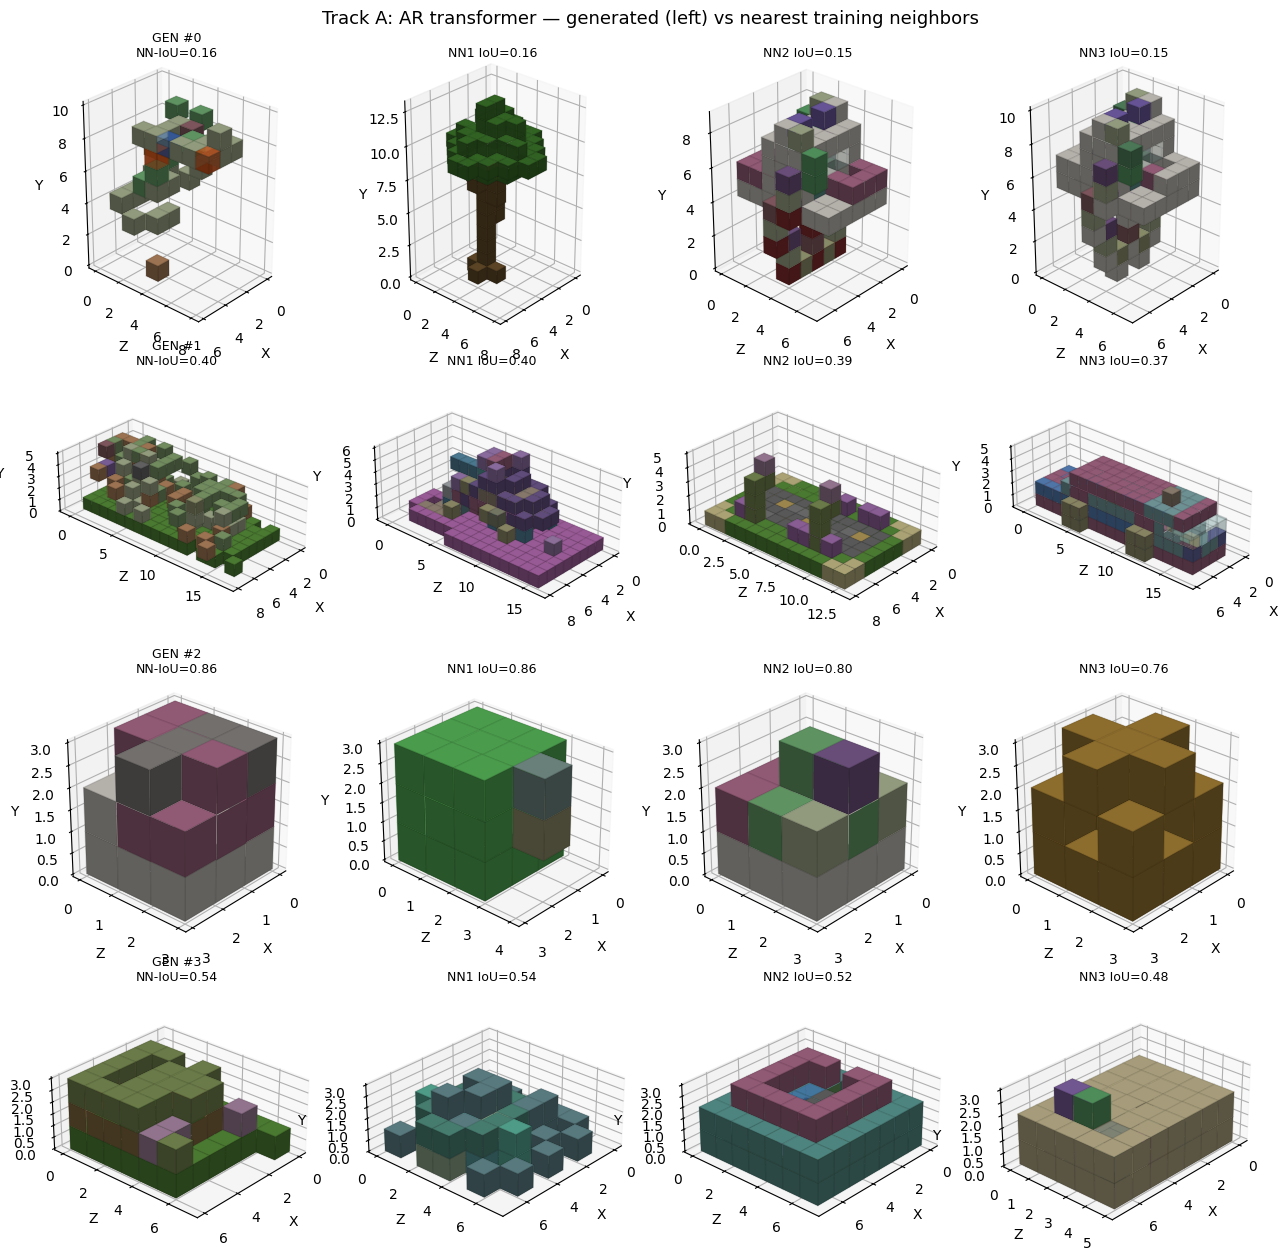

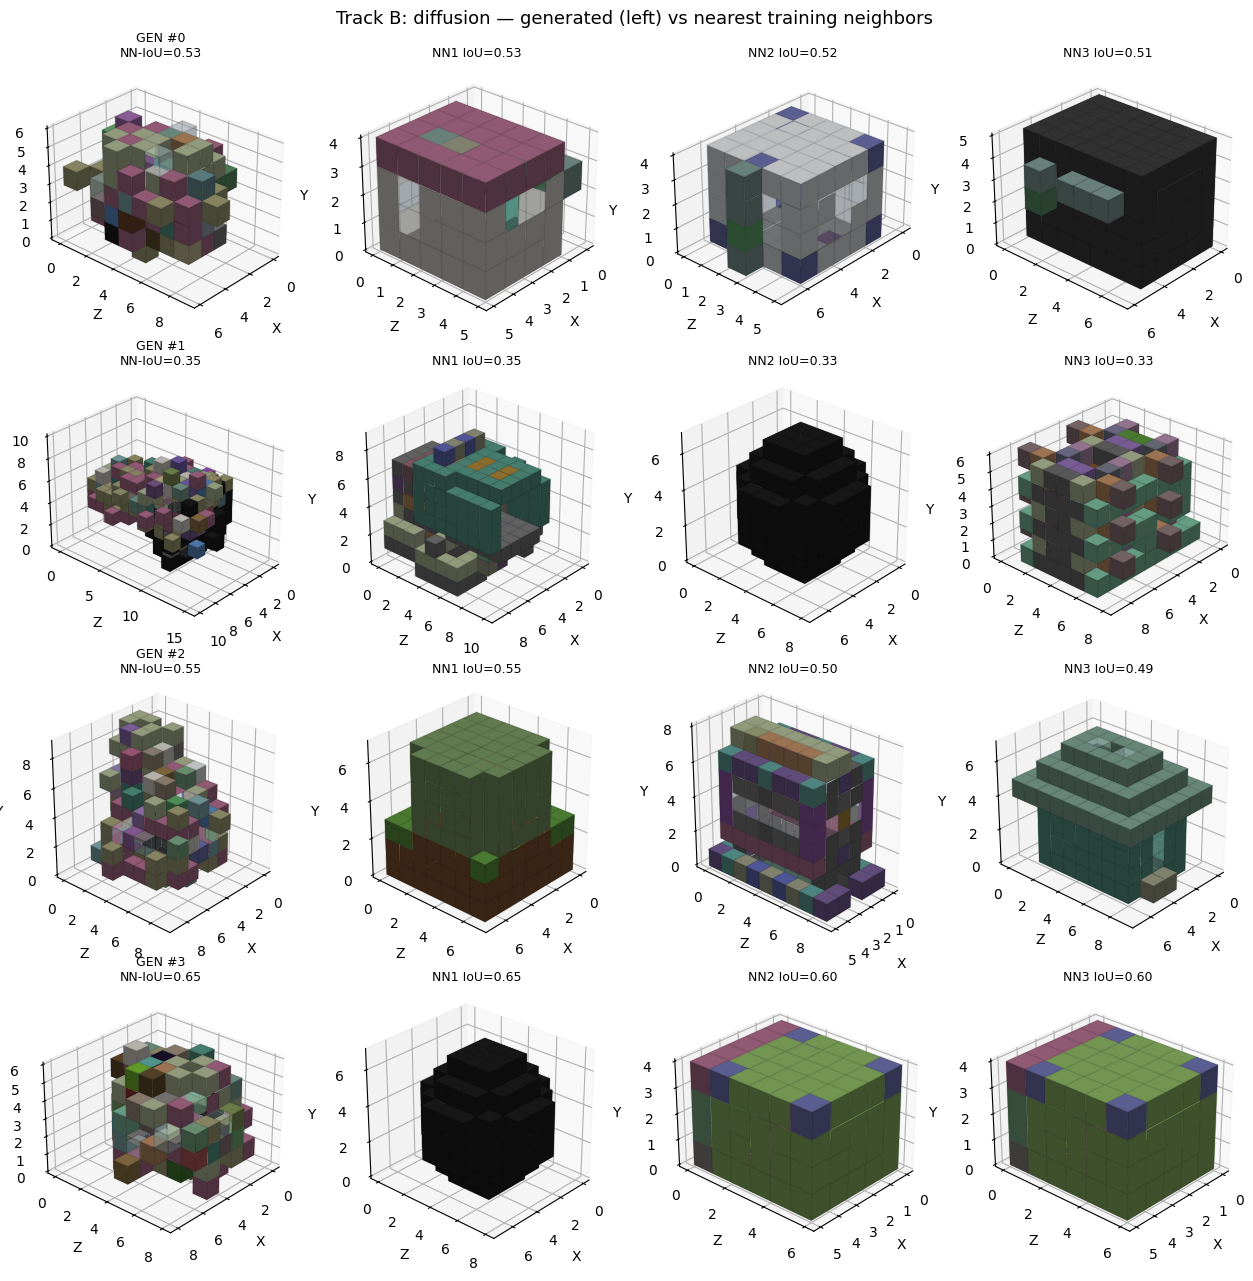

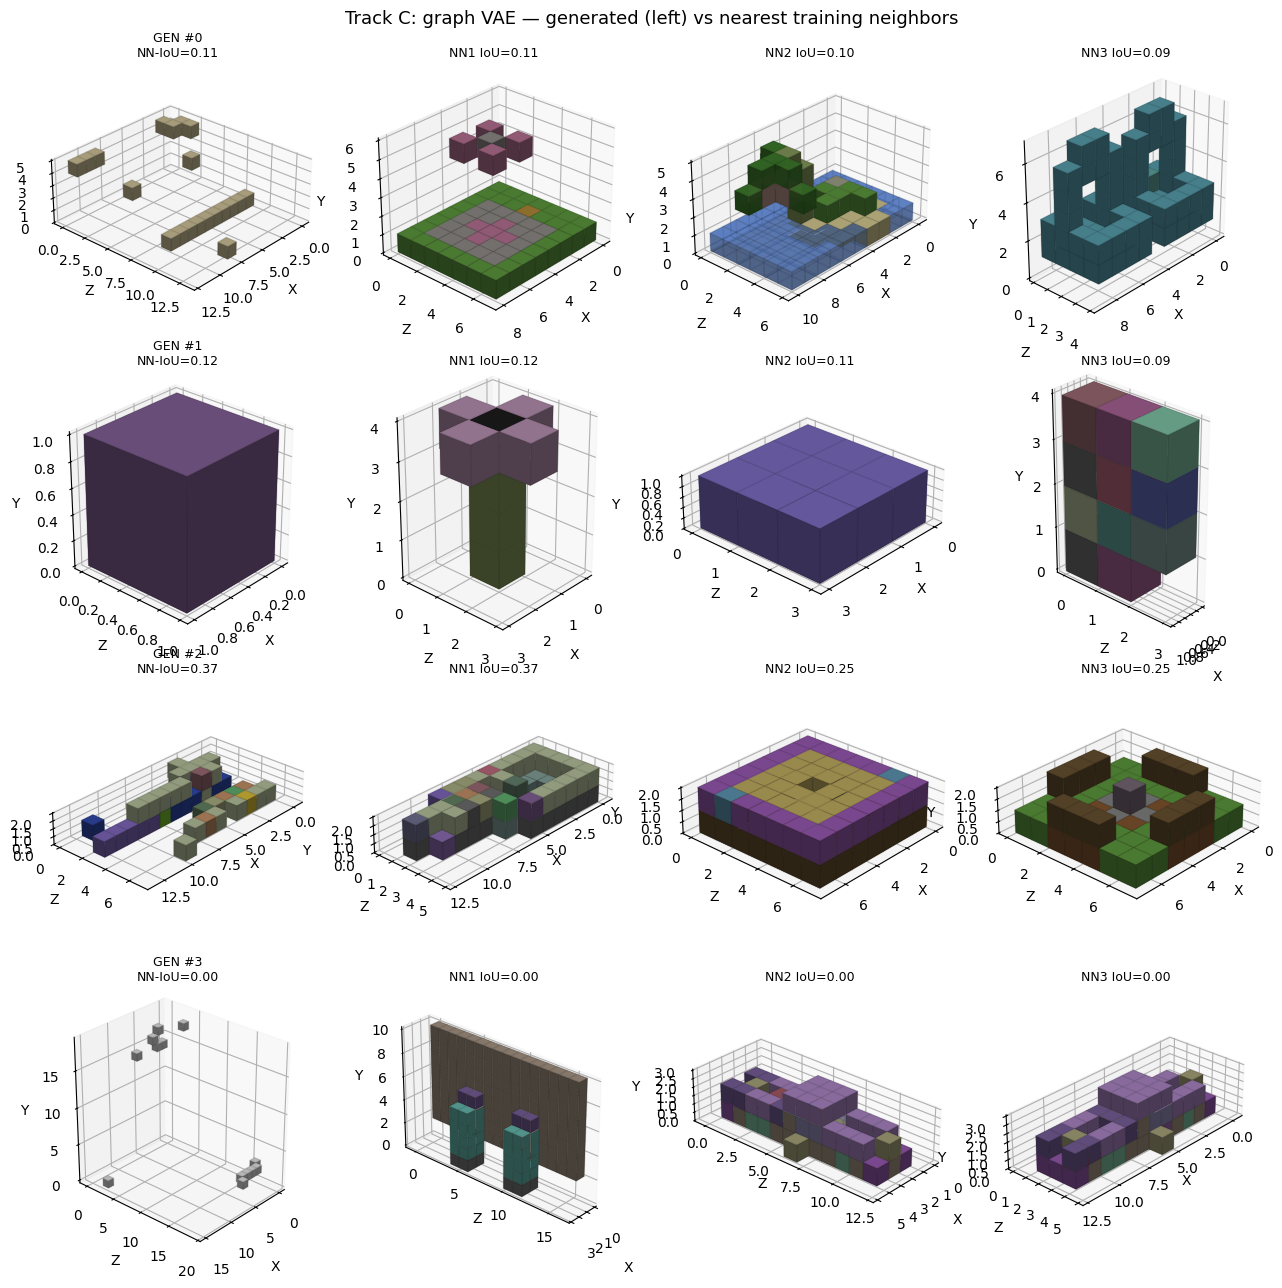

In [8]:
from blockgen.eval.novelty import render_comparison_grid

for name, gen in tracks.items():
    fig = render_comparison_grid(gen, subset, reports[name], num_rows=4, k=3,
                                 title=f"Track {name} — generated (left) vs nearest training neighbors")
    plt.show()

## Takeaways & next steps

- **Variable size** is handled three different ways (EOS token stream, fixed padded grid,
  size-agnostic graph) — all from one shared `Structure` &harr; tokenizer.
- **Novelty** is demonstrated by the low mean NN-IoU and the visual comparison grids.

**Toward the next milestones (medium-agnostic by design):**
- *Tokenized clusters / lego pieces*: replace single-voxel `(X,Y,Z,BLOCK)` tuples in
  `blockgen/utils/serialize.py` with `(piece-type, anchor, orientation)` tuples — Tracks A & C
  reuse unchanged.
- *Electronics*: the block+port graph (Track C) maps directly onto component/pin netlists.
- Scale up: rerun `build_cache` with a larger `--max-dim`, raise `MAX_SEQ_LEN`, and add a
  physics/connectivity validity check (LegoGPT-style rollback) during AR sampling.
